# Evaluating Zero-Shot Time-Series Foundation Models Against Tuned ARIMA
**Macroeconomic Forecasting: Evidence from India's Foreign Trade Volatility**  

This notebook serves as the quantitative execution engine for benchmarking classical Box-Jenkins econometric models against state-of-the-art Time-Series Foundation Models. We rigorously test whether massive-scale pre-training (Amazon Chronos) can genuinely replace the mathematical stationarity transformations of traditional econometrics (ARIMA) when forecasting highly volatile, non-stationary data.  

**Objective:** Predict India's monthly export and import volumes (April 1990 - Feb 2025) across an unprecedented 26-month out-of-sample test window (Jan 2022 - Feb 2025).  

In [31]:
!pip install chronos-forecasting
!pip install transformers accelerate

In [32]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import jarque_bera
from chronos import ChronosPipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

## Data Engineering & Contextualization
We utilize monthly foreign trade data provided by the Reserve Bank of India (RBI). The dataset is split with a strict cutoff at December 2021. The subsequent test window (Jan 2022 - Feb 2025) represents a period of extreme structural instability and post-pandemic volatility, providing a rigorous stress test for both predictive pipelines.

In [33]:
file_name = 'Cleaned_Trade_Data (2).xlsx'
df = pd.read_excel(file_name, sheet_name='Cleaned_Trade_Data (2)')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)
df = df.asfreq('MS')

exports = df['1 Exports US $ Millions'].dropna()
imports = df['2 Imports US $ Millions'].dropna()

In [34]:
train_end = '2021-12-01'
exports_train, exports_test = exports[:train_end], exports['2022-01-01':]
imports_train, imports_test = imports[:train_end], imports['2022-01-01':]
prediction_length = len(exports_test)

## Mathematical Diagnostics & Baseline Optimization
Before deploying complex neural architectures, we establish a mathematically sound statistical baseline.   

1. **Stationarity:** We test for unit roots using the Augmented Dickey-Fuller (ADF) test, applying first-order differencing where necessary.  
2. **Optimization:** Models are evaluated iteratively across various AR and MA lags, optimizing for the lowest Akaike Information Criterion (AIC).  
3. **Residual Analysis:** We ensure the validity of our baseline using the Jarque-Bera test to check for the normal distribution of residuals.  

In [35]:
def check_stationarity(series, name):
    result = adfuller(series)
    print(f"{name} Original p-value: {result[1]:.5f}")
    if result[1] > 0.05:
        diff_result = adfuller(series.diff().dropna())
        print(f"{name} Differenced (d=1) p-value: {diff_result[1]:.5f}\n")

check_stationarity(exports_train, "Exports")
check_stationarity(imports_train, "Imports")

Exports Original p-value: 0.97950
Exports Differenced (d=1) p-value: 0.00001

Imports Original p-value: 0.96465
Imports Differenced (d=1) p-value: 0.00025



In [36]:
model_config = {
    "Exports": {
        "series": exports_train,
        "models": {
            "MA(1)": (0, 0, 1),
            "AR(1)": (1, 0, 0),
            "ARIMA(1,1,1)": (1, 1, 1),
            "ARIMA(3,1,3)": (3, 1, 3) # Optimal
        }
    },
    "Imports": {
        "series": imports_train,
        "models": {
            "MA(1)": (0, 0, 1),
            "AR(1)": (1, 0, 0),
            "ARIMA(1,1,1)": (1, 1, 1),
            "ARIMA(3,1,2)": (3, 1, 2) # Optimal
        }
    }
}

In [37]:
for label, config in model_config.items():
    print(f"\nEvaluating {label} Models:")
    series = config['series']
    for name, order in config['models'].items():
        model = ARIMA(series, order=order).fit()
        residuals = model.resid.dropna()
        jb_stat, jb_pval = jarque_bera(residuals)

        normality = "Normal" if jb_pval > 0.05 else "Non-Normal"
        print(f"[{name}] AIC: {model.aic:.2f} | JB p-value: {jb_pval:.4f} ({normality})")


Evaluating Exports Models:
[MA(1)] AIC: 7739.76 | JB p-value: 0.0000 (Non-Normal)
[AR(1)] AIC: 6842.21 | JB p-value: 0.0000 (Non-Normal)
[ARIMA(1,1,1)] AIC: 6729.45 | JB p-value: 0.0000 (Non-Normal)
[ARIMA(3,1,3)] AIC: 6682.77 | JB p-value: 0.0000 (Non-Normal)

Evaluating Imports Models:
[MA(1)] AIC: 8051.66 | JB p-value: 0.0000 (Non-Normal)
[AR(1)] AIC: 7043.76 | JB p-value: 0.0000 (Non-Normal)
[ARIMA(1,1,1)] AIC: 6991.75 | JB p-value: 0.0000 (Non-Normal)
[ARIMA(3,1,2)] AIC: 6983.29 | JB p-value: 0.0000 (Non-Normal)


## The Classical Baseline (ARIMA)
Following the diagnostic phase, the optimal orders are established as ARIMA(3,1,3) for exports and ARIMA(3,1,2) for imports. These models rely on explicit differencing to handle non-stationarity, establishing our highly interpretable baseline.

In [38]:
final_arima_exports = ARIMA(exports_train, order=(3, 1, 3)).fit()
final_arima_imports = ARIMA(imports_train, order=(3, 1, 2)).fit()

arima_forecast_exports = final_arima_exports.forecast(steps=prediction_length)
arima_forecast_imports = final_arima_imports.forecast(steps=prediction_length)

## The AI Challenger (Amazon Chronos Zero-Shot)
We introduce `amazon/chronos-t5-base`, a Foundation Model that frames time-series forecasting as a tokenized language modeling task.   

Crucially, this model is executed in a **zero-shot** capacity. It receives the historical data up to December 2021 as mathematical context and generates a probabilistic forecast for the next 26 months without any dataset-specific fine-tuning or explicit stationarity transformations.  

In [39]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

In [40]:
context_exports = torch.tensor(exports_train.values)
context_imports = torch.tensor(imports_train.values)

In [41]:
chronos_preds_exports = pipeline.predict(context_exports,
                                         prediction_length=prediction_length,
                                         num_samples=20)
chronos_preds_imports = pipeline.predict(context_imports,
                                         prediction_length=prediction_length,
                                         num_samples=20)

In [42]:
chronos_forecast_exports = np.quantile(chronos_preds_exports[0].numpy(),
                                       0.5, axis=0)
chronos_forecast_imports = np.quantile(chronos_preds_imports[0].numpy(),
                                       0.5, axis=0)

## Rigorous Evaluation & Performance Showdown
We evaluate both paradigms using two distinct risk metrics:
* **Root Mean Squared Error (RMSE):** heavily penalizes large tail-risk deviations and structural misses.  
  $$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$  
* **Mean Absolute Error (MAE):** evaluates the average absolute magnitude of the error.  
  $$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

In [43]:
def evaluate_forecast(asset_name, test_data, arima_pred, chronos_pred):
    print(f"\n========== {asset_name.upper()} FINAL BENCHMARK ==========")
    print(f"ARIMA Baseline  -> RMSE: {np.sqrt(mean_squared_error(test_data,
                                                                 arima_pred))
    :.2f} | MAE: {mean_absolute_error(test_data, arima_pred):.2f}")
    print(f"Chronos (AI)    -> RMSE: {np.sqrt(mean_squared_error(test_data,
                                                                 chronos_pred))
    :.2f} | MAE: {mean_absolute_error(test_data, chronos_pred):.2f}")

evaluate_forecast("Exports", exports_test, arima_forecast_exports, chronos_forecast_exports)
evaluate_forecast("Imports", imports_test, arima_forecast_imports, chronos_forecast_imports)


========== EXPORTS FINAL BENCHMARK ==========
ARIMA Baseline  -> RMSE: 2807.77 | MAE: 2286.24
Chronos (AI)    -> RMSE: 2788.72 | MAE: 2293.52

========== IMPORTS FINAL BENCHMARK ==========
ARIMA Baseline  -> RMSE: 4442.13 | MAE: 3774.50
Chronos (AI)    -> RMSE: 6005.02 | MAE: 4848.03


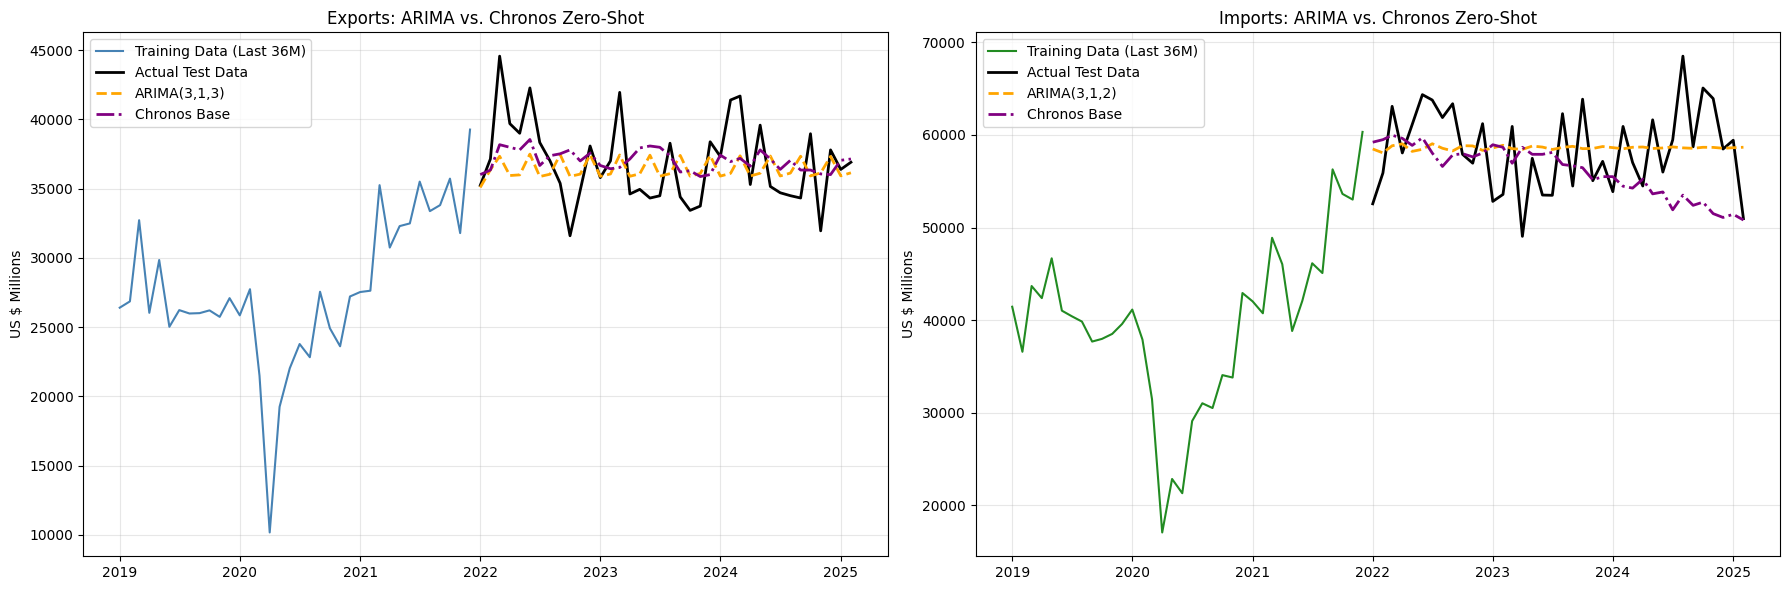

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(exports_train.index[-36:], exports_train.iloc[-36:], label="Training Data (Last 36M)", color="steelblue")
axes[0].plot(exports_test.index, exports_test, label="Actual Test Data", color="black", linewidth=2)
axes[0].plot(exports_test.index, arima_forecast_exports, label="ARIMA(3,1,3)", color="orange", linestyle="--", linewidth=2)
axes[0].plot(exports_test.index, chronos_forecast_exports, label="Chronos Base", color="purple", linestyle="-.", linewidth=2)
axes[0].set_title("Exports: ARIMA vs. Chronos Zero-Shot")
axes[0].set_ylabel("US $ Millions")
axes[0].grid(True, alpha=0.3)
axes[0].legend()


axes[1].plot(imports_train.index[-36:], imports_train.iloc[-36:], label="Training Data (Last 36M)", color="forestgreen")
axes[1].plot(imports_test.index, imports_test, label="Actual Test Data", color="black", linewidth=2)
axes[1].plot(imports_test.index, arima_forecast_imports, label="ARIMA(3,1,2)", color="orange", linestyle="--", linewidth=2)
axes[1].plot(imports_test.index, chronos_forecast_imports, label="Chronos Base", color="purple", linestyle="-.", linewidth=2)
axes[1].set_title("Imports: ARIMA vs. Chronos Zero-Shot")
axes[1].set_ylabel("US $ Millions")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusion
The results demonstrate a critical boundary in zero-shot AI capabilities. For **Exports**, Chronos slightly outperformed ARIMA on RMSE (2788.72 vs 2807.77), showing better resilience to extreme shocks, while ARIMA maintained a tighter MAE. However, for **Imports**, the zero-shot Foundation Model failed significantly, yielding an RMSE of 6005.02 against ARIMA's highly superior 4442.13.

**Verdict:** Massive-scale pre-training does not universally negate the need for explicit stationarity transformations. Classical econometrics remains a significantly safer baseline for specific macroeconomic risk profiles.